---

# Topic Modelling

---

El **Topic Modelling** es un conjunto de técnicas de Procesamiento de Lenguaje Natural (PLN) cuyo objetivo es descubrir automáticamente los **temas latentes** presentes en un conjunto de documentos.

A diferencia del análisis de **keyness**, que identifica las palabras que distinguen grupos previamente definidos, el Topic Modelling busca responder una pregunta diferente:

> **¿Qué temas emergen naturalmente del corpus cuando no conocemos sus categorías de antemano?**

Por esta razón, el Topic Modelling se considera una técnica de **Aprendizaje No Supervisado** (*Unsupervised Machine Learning*).

---

## 🧠 ¿Qué es un tema?

En Topic Modelling, un **tema** (*topic*) no corresponde a una etiqueta predefinida, sino a una **distribución de probabilidad sobre las palabras** del vocabulario.

De manera intuitiva, un tema puede interpretarse como un conjunto de palabras que tienden a aparecer juntas en los documentos y que representan una idea o asunto común.

A su vez, cada documento puede estar compuesto por una mezcla de varios temas en distintas proporciones.

---

### 📌 ¿Cómo funciona?

Los algoritmos de Topic Modelling analizan los patrones de **frecuencia** y **co-ocurrencia** de las palabras para descubrir la estructura temática subyacente del corpus.

El resultado es una representación probabilística que permite:

- descubrir temas presentes en un conjunto de documentos;
- identificar qué documentos están más asociados a cada tema;
- resumir grandes corpus de manera automática;
- explorar colecciones de texto sin necesidad de etiquetas previas.

---

### 📊 Aplicaciones

El Topic Modelling tiene numerosas aplicaciones, entre ellas:

- Exploración de grandes corpus documentales.
- Organización automática de documentos por temática.
- Descubrimiento de tendencias en redes sociales, noticias o publicaciones científicas.
- Apoyo al análisis cualitativo en ciencias sociales, economía y finanzas.

---

## 🔍 El modelo que estudiaremos: **Latent Dirichlet Allocation (LDA)**

En este notebook trabajaremos con **Latent Dirichlet Allocation (LDA)**, uno de los modelos probabilísticos más influyentes en el desarrollo del Topic Modelling.

LDA representa:

- cada **documento** como una mezcla de temas;
- cada **tema** como una distribución de probabilidad sobre las palabras.


> 🧠 **Nota**
>
> Aunque en la actualidad existen métodos más modernos basados en **embeddings** y **transformers**, comprender **Latent Dirichlet Allocation (LDA)** sigue siendo fundamental, ya que constituye la base conceptual del modelamiento probabilístico de tópicos.
>
> En el siguiente notebook exploraremos **BERTopic**, un enfoque moderno que combina **embeddings**, técnicas de agrupamiento (*clustering*) y modelos de lenguaje para obtener tópicos generalmente más coherentes e interpretables.

> 📌 **Idea clave:** Mientras que el análisis de **keyness** compara grupos de documentos conocidos, el **Topic Modelling** descubre automáticamente la estructura temática de un corpus sin utilizar etiquetas previas.

In [56]:
#install.packages("quanteda")
#install.packages("quanteda.textmodels")
#install.packages("topicmodels")


In [57]:
suppressPackageStartupMessages({
  library(quanteda)
  library(quanteda.textmodels)
  library(topicmodels)
})


> **Nota:** El mensaje `Parallel computing: disabled` indica que `quanteda` utilizará un solo núcleo del procesador para ejecutar las operaciones. Esto no afecta los resultados del análisis y, para los conjuntos de datos utilizados en este curso, el rendimiento es más que suficiente.

In [58]:
suppressWarnings(library(data.table))
setDTthreads(16)        # Usa 16 núcleos 
getDTthreads()          # Verifica cuántos núcleos están activos


[1] 16

> **Computación paralela:** Algunas operaciones de `quanteda` y `data.table` pueden ejecutarse utilizando varios núcleos del procesador de forma simultánea. Esto puede reducir significativamente el tiempo de procesamiento cuando se trabaja con grandes corpus. En este ejemplo configuramos `data.table` para utilizar 16 núcleos y verificamos que la configuración se haya aplicado correctamente.

---
---
## I. Preparando los Datos

---
## 🧹 Preprocesamiento de texto para Topic Modelling

Tal como vimos en notebooks anteriores, el preprocesamiento del texto es una etapa fundamental en cualquier proyecto de Procesamiento de Lenguaje Natural (PLN). En el caso del **Topic Modelling**, su objetivo es reducir el ruido léxico y conservar aquellas palabras que aportan información sobre los temas presentes en el corpus.

---

### 🧪 ¿Qué haremos en este notebook?

Antes de aplicar **Latent Dirichlet Allocation (LDA)** realizaremos las siguientes etapas de limpieza:

1. **Eliminar signos de puntuación, símbolos y números**  
   Estos elementos generalmente no aportan información temática y pueden dificultar la identificación de patrones léxicos.

2. **Eliminar palabras vacías (*stopwords*)**  
   Palabras muy frecuentes como *the*, *is*, *and*, *of*, entre otras, poseen escaso contenido temático. Eliminarlas permite que el modelo se concentre en los términos más representativos del corpus.

---

### 🎯 ¿Por qué es importante?

Un buen preprocesamiento permite:

- mejorar la **coherencia** de los tópicos descubiertos;
- reducir el tamaño del vocabulario y el costo computacional;
- eliminar términos poco informativos;
- facilitar la interpretación de los resultados.

En modelos como **LDA**, que se basan en las frecuencias y coocurrencias de las palabras, la calidad del preprocesamiento tiene un impacto directo sobre la calidad de los tópicos obtenidos.

---

> 📌 **Nota:** Más adelante, cuando estudiemos métodos basados en **embeddings**, veremos que algunos pasos de preprocesamiento dejan de ser tan críticos como en los modelos clásicos basados en Bag-of-Words, como LDA.

---
## 🎬 Continuaremos trabajando con las críticas de cine

En este notebook seguiremos utilizando el corpus de **críticas de películas de Pang & Lee (2004)** que introdujimos en el notebook anterior.

Hasta ahora empleamos este corpus para realizar análisis de frecuencia, *keyness* y concordancias (*KWIC*). Ahora lo utilizaremos para un objetivo distinto: **descubrir automáticamente los temas presentes en las reseñas** mediante **Topic Modelling**.

Al trabajar con el mismo corpus podremos comparar cómo distintas técnicas de Procesamiento de Lenguaje Natural permiten responder preguntas diferentes sobre un mismo conjunto de documentos.

> 📌 **Idea clave:** El corpus no cambia; lo que cambia es la pregunta de investigación. Mientras que el análisis de *keyness* buscaba identificar palabras que distinguían reseñas positivas y negativas, el **Topic Modelling** busca descubrir automáticamente los temas latentes presentes en las reseñas.

In [59]:
toks <- data_corpus_moviereviews %>%
  tokens(remove_punct = TRUE, remove_symbols = TRUE, remove_numbers = TRUE) %>%
  tokens_remove(stopwords("en"))
toks



Tokens consisting of 2,000 documents and 3 docvars.
cv000_29416.txt :
 [1] "plot"     "two"      "teen"     "couples"  "go"       "church"  
 [7] "party"    "drink"    "drive"    "get"      "accident" "one"     
[ ... and 314 more ]

cv001_19502.txt :
 [1] "happy"     "bastard's" "quick"     "movie"     "review"    "damn"     
 [7] "y2k"       "bug"       "got"       "head"      "start"     "movie"    
[ ... and 118 more ]

cv002_17424.txt :
 [1] "movies"    "like"      "make"      "jaded"     "movie"     "viewer"   
 [7] "thankful"  "invention" "timex"     "indiglo"   "watch"     "based"    
[ ... and 250 more ]

cv003_12683.txt :
 [1] "quest"          "camelot"        "warner"         "bros"          
 [5] "first"          "feature-length" "fully-animated" "attempt"       
 [9] "steal"          "clout"          "disney's"       "cartoon"       
[ ... and 258 more ]

cv004_12641.txt :
 [1] "synopsis"      "mentally"      "unstable"      "man"          
 [5] "undergoing"    "psychother

---
### 🔗 `tokens_compound()`

La función **`tokens_compound()`** permite combinar **tokens consecutivos** en una única unidad léxica. De esta forma, expresiones compuestas pueden analizarse como un solo término en lugar de varias palabras independientes.

---

### 🧠 ¿Por qué es útil?

Muchas expresiones adquieren su significado únicamente cuando se consideran como una unidad.

Por ejemplo:

- `"New York"`
- `"human rights"`
- `"machine learning"`
- `"Star Wars"`

Si estas expresiones se dividen en palabras individuales, parte de su significado puede perderse durante el análisis.

Con `tokens_compound()`, estas secuencias pueden transformarse en un único token, por ejemplo:

- `New_York`
- `human_rights`
- `machine_learning`
- `Star_Wars`

---

### 🎬 Aplicación al corpus de críticas de películas

En nuestro corpus de reseñas de cine, esta función resulta especialmente útil para preservar entidades como:

- títulos de películas;
- nombres de franquicias;
- nombres propios de personajes o actores;
- expresiones frecuentes con significado específico.

Por ejemplo, distinguir correctamente **"Star Wars"** de **"Star Trek"** puede mejorar la interpretación de los tópicos descubiertos por el modelo.

---

### 🎯 ¿Por qué es importante para LDA?

LDA trabaja con un modelo **Bag-of-Words**, donde cada término del vocabulario constituye una unidad independiente.

Si una expresión compuesta se divide en varias palabras, el modelo puede distribuirlas entre distintos tópicos y perder parte de su significado.

Al preservar estas expresiones como un único token, aumentamos la probabilidad de que el modelo identifique temas más coherentes e interpretables.

---

> 📌 **Nota:** El uso de `tokens_compound()` es especialmente beneficioso en modelos clásicos basados en Bag-of-Words, como **LDA**. Más adelante veremos que los métodos modernos basados en **embeddings** capturan parte de estas relaciones semánticas de manera más natural.

---

Veamos un ejemplo:

In [60]:
example <- tokens("This is the third award winning movie of Cameron")

In [61]:
print(example)

Tokens consisting of 1 document.
text1 :
[1] "This"    "is"      "the"     "third"   "award"   "winning" "movie"  
[8] "of"      "Cameron"



 🤓 El clásico "foo":

In [62]:
foo <- tokens_compound(example, phrase("award winning"), concatenator = "-")
print(foo)

Tokens consisting of 1 document.
text1 :
[1] "This"          "is"            "the"           "third"        
[5] "award-winning" "movie"         "of"            "Cameron"      



---
Volvamos al corpus de las críticas de cine:

In [63]:
toks <- tokens_compound(toks, phrase(c("star wars", "star trek")))
toks

Tokens consisting of 2,000 documents and 3 docvars.
cv000_29416.txt :
 [1] "plot"     "two"      "teen"     "couples"  "go"       "church"  
 [7] "party"    "drink"    "drive"    "get"      "accident" "one"     
[ ... and 314 more ]

cv001_19502.txt :
 [1] "happy"     "bastard's" "quick"     "movie"     "review"    "damn"     
 [7] "y2k"       "bug"       "got"       "head"      "start"     "movie"    
[ ... and 118 more ]

cv002_17424.txt :
 [1] "movies"    "like"      "make"      "jaded"     "movie"     "viewer"   
 [7] "thankful"  "invention" "timex"     "indiglo"   "watch"     "based"    
[ ... and 250 more ]

cv003_12683.txt :
 [1] "quest"          "camelot"        "warner"         "bros"          
 [5] "first"          "feature-length" "fully-animated" "attempt"       
 [9] "steal"          "clout"          "disney's"       "cartoon"       
[ ... and 258 more ]

cv004_12641.txt :
 [1] "synopsis"      "mentally"      "unstable"      "man"          
 [5] "undergoing"    "psychother

---
## ✂️ Reducción del vocabulario

Antes de ajustar el modelo **LDA**, eliminaremos las palabras muy poco frecuentes utilizando `dfm_trim()`.

En este ejemplo conservaremos únicamente aquellas palabras que aparecen **al menos cinco veces** en todo el corpus (`min_termfreq = 5`).

Este filtrado permite:

- reducir el tamaño del vocabulario;
- eliminar términos extremadamente raros, que suelen aportar poca información temática;
- disminuir el costo computacional;
- mejorar la estabilidad e interpretabilidad de los tópicos obtenidos.

El valor `min_termfreq = 5` se utiliza únicamente con fines ilustrativos. En aplicaciones reales, este umbral depende del tamaño y las características del corpus.

> 📌 **Idea clave:** LDA identifica patrones de coocurrencia entre palabras. Eliminar términos extremadamente infrecuentes ayuda a que esos patrones sean más estables y fáciles de interpretar.

In [64]:
dfmat <- dfm(toks) %>%
  dfm_trim(min_termfreq = 5)
dfmat


Document-feature matrix of: 2,000 documents, 14,873 features (98.37% sparse) and 3 docvars.
                 features
docs              plot two teen couples go church party drink drive get
  cv000_29416.txt    1   2    4       1  2      1     1     1     1   3
  cv001_19502.txt    0   0    0       0  0      0     0     0     0   1
  cv002_17424.txt    2   1    0       0  2      0     0     0     0   0
  cv003_12683.txt    0   0    0       0  0      0     0     0     0   0
  cv004_12641.txt    1   1    0       0  0      0     0     0     0   0
  cv005_29357.txt    1   0    0       0  0      0     0     0     0   0
[ reached max_ndoc ... 1,994 more documents, reached max_nfeat ... 14,863 more features ]

---
---

## II. Ajustando un Topic Model

---
## 🔄 Conversión a una `DocumentTermMatrix`

Hasta ahora hemos representado el corpus mediante una **Document-Feature Matrix (`dfm`)** de `quanteda`, donde las filas corresponden a documentos, las columnas a términos y las celdas contienen sus frecuencias.

Sin embargo, el paquete **`topicmodels`**, que implementa **Latent Dirichlet Allocation (LDA)**, utiliza una estructura de datos diferente: la **`DocumentTermMatrix`** del paquete `tm`.

La función `convert()` permite transformar automáticamente un objeto `dfm` al formato requerido por `topicmodels`, sin modificar el contenido de la matriz.

---

> 📌 **Idea clave:** Es frecuente que distintos paquetes de R utilicen estructuras de datos propias. La función `convert()` permite combinar el preprocesamiento realizado con `quanteda` con los algoritmos implementados en `topicmodels`.
>
> 🔍 **Observación:** Si inspeccionamos ambos objetos, veremos que contienen esencialmente la misma información (documentos, términos y frecuencias). La diferencia es principalmente **interna**: cambia la clase y la forma en que los datos se almacenan en memoria, no su contenido.

In [65]:
dfmat_tm <- convert(dfmat, to = "topicmodels")

In [66]:
class(dfmat)
class(dfmat_tm)

dim(dfmat)
dim(dfmat_tm)

[1] "dfm"
attr(,"package")
[1] "quanteda"

[1] "DocumentTermMatrix"    "simple_triplet_matrix"

[1]  2000 14873

[1]  2000 14873

---
## 📚 Latent Dirichlet Allocation (LDA)

**Latent Dirichlet Allocation (LDA)** es uno de los algoritmos de *Topic Modelling* más utilizados para descubrir automáticamente los **tópicos latentes** presentes en un corpus.

LDA parte de dos ideas fundamentales:

- cada **documento** es una mezcla de distintos **tópicos**;
- cada **tópico** es una distribución de probabilidad sobre las palabras del vocabulario.

A diferencia del análisis de *keyness*, LDA no necesita conocer previamente las categorías de los documentos. En cambio, infiere automáticamente los tópicos a partir de los patrones de coocurrencia de las palabras.

---

### 🎯 ¿Qué obtiene LDA?

Una vez ajustado el modelo, LDA estima:

- la distribución de tópicos para cada documento;
- la distribución de palabras para cada tópico.

Estas dos distribuciones permiten identificar los principales temas presentes en el corpus y determinar qué documentos están más asociados a cada uno de ellos.

> 📌 **Idea clave:** LDA es un método de **aprendizaje no supervisado**, ya que descubre automáticamente la estructura temática del corpus sin utilizar etiquetas previas.




---
## ⚙️ ¿Cómo funciona LDA?

LDA es un **modelo probabilístico generativo**. De forma simplificada, supone que cada palabra de un documento se genera mediante el siguiente proceso:

1. Se selecciona un **tópico** según la distribución de tópicos del documento.
2. A partir de ese tópico, se selecciona una **palabra** según la distribución de palabras asociada al tópico.

Este proceso se repite para todas las palabras del documento.

![¿Cómo funciona LDA? Proceso generativo de una palabra en un documento](../images/LDA_plot.png)

Durante el entrenamiento, el algoritmo observa únicamente las palabras presentes en el corpus e intenta inferir cuáles fueron las distribuciones de tópicos y palabras que podrían haber generado esos documentos.

Aunque el proceso real es probabilístico y se basa en distribuciones de Dirichlet, conceptualmente puede entenderse como un procedimiento iterativo que ajusta ambas distribuciones hasta encontrar una representación consistente del corpus.

> 📌 **En otras palabras:** LDA no observa directamente los tópicos; los estima a partir de los patrones de aparición conjunta de las palabras.

![Topic Modelling: corpus, mezcla de tópicos y distribución de palabras](../images/topic_modeling_plot.png)

---
## 🔢 La distribución de Dirichlet

El nombre **Latent Dirichlet Allocation (LDA)** proviene del hecho de que las dos distribuciones de probabilidad del modelo se suponen generadas a partir de una **distribución de Dirichlet**.

En LDA se asume que:

$$
\theta \sim \mathrm{Dir}(\boldsymbol{\alpha})
$$

y

$$
\phi \sim \mathrm{Dir}(\boldsymbol{\beta}).
$$

Aquí,

- **θ** representa la **distribución de tópicos de un documento**;
- **φ** representa la **distribución de palabras de un tópico**.

La notación

$$
\mathrm{Dir}(\boldsymbol{\alpha})
$$

significa que **θ sigue una distribución de Dirichlet** cuyos parámetros son el vector

$$
\boldsymbol{\alpha}
=
(\alpha_1,\alpha_2,\ldots,\alpha_K),
$$

donde \(K\) es el número de tópicos.

De manera análoga,

$$
\mathrm{Dir}(\boldsymbol{\beta})
$$

indica que **φ sigue una distribución de Dirichlet** parametrizada por el vector

$$
\boldsymbol{\beta}
=
(\beta_1,\beta_2,\ldots,\beta_V),
$$

donde \(V\) corresponde al tamaño del vocabulario.

---

### 📊 Función de densidad de la distribución de Dirichlet

Para un vector de probabilidades

$$
\theta=(\theta_1,\ldots,\theta_K),
$$

tal que

$$
\sum_{k=1}^{K}\theta_k=1,
\qquad
\theta_k\ge0,
$$

la función de densidad viene dada por

$$
f(\theta;\boldsymbol{\alpha})
=
\frac{\Gamma\!\left(\sum_{k=1}^{K}\alpha_k\right)}
{\displaystyle\prod_{k=1}^{K}\Gamma(\alpha_k)}
\prod_{k=1}^{K}\theta_k^{\,\alpha_k-1}.
$$

---

### ⚙️ ¿Qué son α y β?

Los vectores **α** y **β** son **hiperparámetros** del modelo.

A diferencia de **θ** y **φ**, que son distribuciones de probabilidad estimadas por LDA, los hiperparámetros **α** y **β** controlan la forma que pueden adoptar esas distribuciones antes de observar los datos.

En particular,

- **α** controla cómo se distribuyen los **tópicos dentro de los documentos**.
  - Un **α pequeño** favorece documentos dominados por pocos tópicos.
  - Un **α grande** favorece documentos que mezclan muchos tópicos.

- **β** controla cómo se distribuyen las **palabras dentro de cada tópico**.
  - Un **β pequeño** favorece tópicos definidos por pocas palabras muy representativas.
  - Un **β grande** produce tópicos con distribuciones de palabras más uniformes.

---

> 📌 **Idea clave:** La distribución de Dirichlet garantiza que tanto **θ** como **φ** sean **vectores de probabilidades**: todos sus elementos son no negativos y sus componentes suman exactamente uno.

---
## ⚙️ Parámetros principales de `topicmodels::LDA()`

La función `LDA()` del paquete `topicmodels` permite ajustar un modelo de **Latent Dirichlet Allocation**.

Los parámetros más importantes son:

- **`k`**: número de tópicos que se desea descubrir.
- **`method`**: algoritmo utilizado para estimar el modelo (por ejemplo, `"VEM"` o `"Gibbs"`).
- **`control`**: lista de opciones que permite controlar aspectos como el número de iteraciones, la semilla aleatoria y otros hiperparámetros.

En las siguientes secciones analizaremos con mayor detalle estos parámetros y cómo afectan los resultados obtenidos por el modelo.

---

> 📌 **Observación:** La elección del número de tópicos (`k`) suele ser una de las decisiones más importantes en un análisis de Topic Modelling.

---
## ⚙️ Métodos de Estimación en LDA: VEM vs. Gibbs Sampling

Cuando se entrena un modelo **Latent Dirichlet Allocation (LDA)**, es necesario utilizar un método de inferencia para estimar las distribuciones de tópicos y palabras. Los dos métodos más comunes en R (`topicmodels::LDA`) son:

---

### 🔹 VEM – Variational Expectation-Maximization

- Utiliza una técnica de **optimización determinística**.
- Se basa en aproximar las distribuciones de probabilidad mediante funciones más manejables (variacionales).
- Converge rápidamente y es adecuado para conjuntos de datos grandes.
- Método por defecto en `topicmodels`.

**Ventajas**: Rápido, reproducible (menos aleatoriedad).  
**Desventajas**: Puede subestimar la variabilidad y quedar atrapado en óptimos locales.

---

### 🔸 Gibbs Sampling

- Es un método de **MCMC (Markov Chain Monte Carlo)** basado en simulaciones aleatorias.
- Asigna iterativamente tópicos a palabras utilizando muestreo condicional.
- Tiende a capturar mejor la **estructura real** del modelo, especialmente en corpora pequeños o ruidosos.

**Ventajas**: Estimaciones más precisas y flexibles.  
**Desventajas**: Más lento, necesita muchas iteraciones, resultado más sensible a la semilla.

---

### 🧠 ¿Cuál usar?

- **VEM**: cuando se necesita rapidez, reproducibilidad y se trabaja con grandes volúmenes de texto.
- **Gibbs**: cuando se prioriza la calidad de la inferencia y se dispone de mayor poder computacional.

> ✅ Ambos métodos buscan el mismo objetivo: estimar la distribución de tópicos y palabras en el corpus. La elección depende del equilibrio entre precisión y velocidad.


---
## 🧪 Estimación de un modelo LDA con Gibbs Sampling

En este paso, se entrena un modelo de **Latent Dirichlet Allocation (LDA)** utilizando el método de inferencia **Gibbs Sampling**. El modelo se ajusta sobre la matriz documento-término previamente convertida y especifica que se desea identificar **20 tópicos** latentes en el corpus.

---

### ⚙️ Parámetros clave

- **`k = 20`**: Se define que el modelo debe extraer 20 tópicos.
- **`method = "Gibbs"`**: Se emplea el muestreador de Gibbs, un algoritmo MCMC que realiza inferencia estocástica.
- **`alpha = 0.02`**: Controla la dispersión de tópicos por documento. Un valor bajo tiende a generar documentos con pocos temas dominantes.
- **`delta = 0.02`** (a veces llamado `beta` en la literatura): Controla la dispersión de palabras por tópico. Un valor bajo produce tópicos más especializados (menos palabras comunes compartidas entre tópicos).
- **`set.seed(2)`**: Se establece una semilla para asegurar la reproducibilidad de los resultados.

---

### 🧠 ¿Qué produce este modelo?

Al finalizar la estimación, el modelo entrega:

- Una **distribución de tópicos por documento** (¿qué temas predominan en cada texto?).
- Una **distribución de palabras por tópico** (¿qué palabras caracterizan cada tema?).

Estas salidas permiten interpretar el contenido latente del corpus y explorar la estructura temática de los documentos.

> ✅ Gibbs Sampling es especialmente útil cuando se busca capturar estructuras semánticas más precisas, aunque requiere mayor poder de cómputo que métodos deterministas como VEM.


---
> **📝 Nota sobre la notación**
>
> En la formulación original de **Latent Dirichlet Allocation (LDA)** propuesta por **Blei, Ng y Jordan (2003)**, el hiperparámetro asociado a la distribución de palabras por tópico se denota por **β**, mientras que el hiperparámetro asociado a la distribución de tópicos por documento se denota por **α**.
>
> En este notebook seguimos esa notación al presentar el modelo:
>
> - **θ**: distribución de tópicos de un documento.
> - **φ**: distribución de palabras de un tópico.
> - **α**: hiperparámetro de la distribución de Dirichlet sobre **θ**.
> - **β**: hiperparámetro de la distribución de Dirichlet sobre **φ**.
>
> Sin embargo, la implementación del paquete **`topicmodels`** utiliza el nombre **`delta`** en lugar de **`beta`** para este último hiperparámetro. Es decir,
>
> $$
> \boxed{\texttt{delta} \equiv \beta}
> $$
>
> Ambos representan exactamente el mismo concepto: el hiperparámetro que controla la distribución previa (*prior*) de las palabras dentro de cada tópico.
>
> **Referencia:** Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). *Latent Dirichlet Allocation*. Journal of Machine Learning Research, **3**, 993–1022.

In [67]:
set.seed(2)
tmod_20 <- LDA(dfmat_tm,
            k = 20,
            method = "Gibbs",
            control = list(alpha = 0.02, delta = 0.02))

---
## 🏷️ Principales palabras de cada tópico

Una vez ajustado el modelo LDA, podemos inspeccionar los **tópicos descubiertos** mediante la función `terms()`.

La instrucción

```r
terms(tmod_20, 15)
```

devuelve, para cada uno de los **20 tópicos** estimados por el modelo (`k = 20`), las **15 palabras con mayor probabilidad** dentro de ese tópico.

Es importante destacar que:

- estas palabras **no son simplemente las más frecuentes del corpus**;
- corresponden a las palabras con mayor probabilidad en la distribución **φ** (*topic-word distribution*) estimada para cada tópico;
- el conjunto de palabras permite interpretar el significado semántico de cada tópico.

Por ejemplo, un tópico cuyas palabras principales sean

```
government   president   law   congress   state
```

podría interpretarse como un tópico relacionado con **política**.

---

> 📌 **Idea clave:** LDA no asigna nombres a los tópicos. El investigador interpreta cada tópico a partir de las palabras con mayor probabilidad en su distribución **φ**.

In [68]:
terms(tmod_20, 15)


Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
action,sex,harry,new,love,alien,crime,disney,school,horror,star_wars,comedy,batman,white,world,war,film,movie,comedy,film
jackie,characters,character,joe,family,aliens,police,animated,high,scream,effects,john,robin,political,city,men,one,one,funny,music
chan,woman,sam,godzilla,story,ship,cop,animation,truman,killer,lucas,funny,arnold,black,dark,action,like,just,jokes,original
van,mr,williams,tom,romantic,effects,plot,story,life,vampire,phantom,brothers,action,american,game,army,story,like,humor,girls
fight,scene,simon,wild,life,planet,jackie,tarzan,town,scary,menace,jeff,kevin,flynt,computer,battle,movie,film,murphy,musical
plot,sexual,max,york,father,space,action,voice,show,original,special,big,mr,god,reality,ryan,also,good,laughs,spice
hong,women,good,west,mother,science,tarantino,toy,jim,summer,jedi,crystal,comic,larry,reeves,soldiers,can,get,eddie,dvd
kong,nights,things,island,woman,mars,de,kids,teacher,know,impact,dude,spawn,look,angels,jones,even,bad,make,world
bond,film's,patch,smith,wedding,earth,robert,mulan,football,sequel,young,nbsp,tim,derek,matrix,private,character,even,gags,band
chinese,party,douglas,disaster,comedy,crew,pulp,family,carrey,blair,armageddon,money,apes,lawyer,human,gibson,two,really,laugh,version


In [69]:
class(terms(tmod_20, 15))

[1] "matrix" "array"

💡 ¡Veamos qué opinan ChatGPT y Claude!

In [70]:
# Extraer los 15 términos principales de cada tópico
tabla_terminos <- terms(tmod_20, 15)

# Convertir la matriz en un data frame
tabla_terminos <- as.data.frame(tabla_terminos)

# Crear y guardar una tabla HTML
html <- knitr::kable(
  tabla_terminos,
  format = "html",
  caption = "15 términos principales por tópico"
)

writeLines(
  c(
    "<!DOCTYPE html>",
    "<html lang='es'>",
    "<head>",
    "<meta charset='UTF-8'>",
    "<title>Términos por tópico</title>",
    "</head>",
    "<body>",
    html,
    "</body>",
    "</html>"
  ),
  "terminos_tmod_20.html"
)

---
## 🎯 Elección del número de tópicos ($k$) en LDA

El parámetro $k$ determina el número de tópicos que el modelo **Latent Dirichlet Allocation (LDA)** intentará descubrir en el corpus. Su elección influye directamente en la calidad del modelo, la interpretabilidad de los tópicos y el costo computacional.



### 🔻 Cuando $k$ es demasiado bajo

Un número insuficiente de tópicos puede producir **underfitting**:

- conceptos diferentes quedan agrupados dentro de un mismo tópico;
- los tópicos son demasiado amplios y poco específicos;
- se pierden detalles importantes de la estructura temática del corpus;
- disminuye la capacidad del modelo para distinguir entre documentos.

---

### 🔺 Cuando $k$ es demasiado alto

Un número excesivo de tópicos puede producir **overfitting**:

- aparecen tópicos muy similares o redundantes;
- temas generales se fragmentan en numerosos subtemas poco diferenciados;
- el modelo puede capturar ruido o particularidades poco relevantes del corpus;
- aumenta el tiempo de entrenamiento y la complejidad computacional.

---

### ✅ Un valor adecuado de $k$

El objetivo es encontrar un valor de $k$ que produzca tópicos:

- coherentes semánticamente;
- claramente diferenciados entre sí;
- suficientemente específicos para describir el corpus sin fragmentarlo excesivamente;
- útiles para la interpretación posterior.

![Efecto del número de tópicos ($k$) en un modelo LDA. Un valor de $k$ demasiado bajo produce tópicos muy generales (underfitting), un valor adecuado genera tópicos coherentes y diferenciados, mientras que un valor demasiado alto produce tópicos fragmentados o redundantes (overfitting).](../images/LDA_k_selection.png)

---

## 🧭 ¿Cómo escoger $k$?

No existe un valor universalmente óptimo de $k$. En la práctica, suele combinarse información proveniente de distintos criterios, entre ellos:

- medidas de **coherencia temática**;
- **log-verosimilitud** u otras métricas de ajuste;
- comparación de modelos con diferentes valores de $k$;
- interpretación cualitativa de los tópicos obtenidos.

> 📌 **Idea clave:** La elección de $k$ consiste en encontrar un equilibrio entre una representación demasiado general (**underfitting**) y una excesivamente fragmentada (**overfitting**). El mejor valor depende tanto del corpus como de los objetivos del análisis.

Reptimaos nuestro análisis con $k=12$ y con $k=25$:

In [71]:
set.seed(2)
tmod_12 <- LDA(dfmat_tm,
            k = 12 , 
            method = "Gibbs",
            control = list(alpha = 0.02, delta = 0.02))

In [72]:
terms(tmod_12, 15)

Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12
action,wild,love,alien,batman,scream,effects,disney,war,film,movie,funny
jackie,sex,life,ship,vampire,horror,star_wars,story,movie,one,film,comedy
plot,girls,family,aliens,wife,school,special,animated,political,story,one,jokes
crime,party,romantic,effects,robin,killer,movie,voice,men,like,just,movie
cop,scene,comedy,planet,book,high,space,animation,american,character,like,big
chan,harry,woman,action,arnold,summer,science,tarzan,black,characters,good,humor
s,drug,town,mars,vampires,teen,series,original,white,also,even,laughs
movies,house,father,earth,action,characters,star_trek,king,army,life,get,comic
films,joe,mother,crew,murder,still,computer,family,ryan,can,really,john
police,nights,relationship,special,comic,julie,lucas,musical,spielberg,much,bad,brothers


In [73]:
# Extraer los 15 términos principales de cada tópico
tabla_terminos <- terms(tmod_12, 15)

# Convertir la matriz en un data frame
tabla_terminos <- as.data.frame(tabla_terminos)

# Crear la tabla HTML
html <- knitr::kable(
  tabla_terminos,
  format = "html",
  caption = "15 términos principales por tópico (Modelo con 12 tópicos)"
)

# Guardar el archivo HTML
writeLines(
  c(
    "<!DOCTYPE html>",
    "<html lang='es'>",
    "<head>",
    "<meta charset='UTF-8'>",
    "<title>Términos por tópico</title>",
    "<style>",
    "body {font-family: Arial, sans-serif; margin: 40px;}",
    "table {border-collapse: collapse; width: 100%;}",
    "th, td {border: 1px solid #ccc; padding: 6px; text-align: center;}",
    "th {background-color: #f2f2f2;}",
    "caption {font-size: 1.2em; font-weight: bold; margin-bottom: 10px;}",
    "</style>",
    "</head>",
    "<body>",
    html,
    "</body>",
    "</html>"
  ),
  "terminos_tmod_12.html"
)

cat("Archivo HTML guardado en:\n", normalizePath("terminos_tmod_12.html"))

Archivo HTML guardado en:
 /Users/fernandodiaz/NLP/docs/clases/terminos_tmod_12.html

In [74]:
set.seed(2)
tmod_25 <- LDA(dfmat_tm,
            k = 25 , 
            method = "Gibbs",
            control = list(alpha = 0.02, delta = 0.02))

In [75]:
terms(tmod_25, 15)

Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,⋯,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20,Topic 21,Topic 22,Topic 23,Topic 24,Topic 25
action,cop,life,war,godzilla,joe,film,planet,school,comedy,⋯,sex,case,good,film,music,alien,movie,batman,movie,house
jackie,crime,family,men,new,simon,ship,effects,things,funny,⋯,women,murder,jones,one,love,science,film,robin,bad,spawn
chan,jackie,love,battle,max,dog,titanic,alien,high,jokes,⋯,characters,lawyer,nick,like,musical,world,just,mr,like,football
van,vampire,father,army,york,douglas,girls,space,harry,humor,⋯,drug,flynt,movie,movie,mr,dark,good,arnold,one,wrestling
fight,police,man,action,species,ghost,spice,earth,wild,laughs,⋯,writer,performance,big,just,nights,aliens,like,evil,even,team
hong,action,mother,west,crystal,novel,video,special,sam,movie,⋯,porn,courtroom,hunting,can,king,computer,one,dr,get,special
bond,de,town,private,broderick,book,dvd,mars,bill,bob,⋯,party,carter,prison,time,song,city,really,comic,around,baseball
kong,tarantino,woman,ryan,island,playing,home,action,sex,hilarious,⋯,picture,prison,dude,even,shakespeare,effects,get,series,kill,fight
chinese,jack,home,soldiers,first,allen,version,ship,campbell,smith,⋯,sexual,mystery,fugitive,story,rock,fiction,bad,carrey,guy,league
martial,vampires,husband,wild,effects,helen,story,crew,henry,ben,⋯,sarah,kevin,lebowski,much,boogie,matrix,see,austin,action,blues


In [76]:
# Extraer los 15 términos principales de cada tópico
tabla_terminos <- terms(tmod_25, 15)

# Convertir la matriz en un data frame
tabla_terminos <- as.data.frame(tabla_terminos)

# Crear la tabla HTML
html <- knitr::kable(
  tabla_terminos,
  format = "html",
  caption = "15 términos principales por tópico (Modelo con 25 tópicos)"
)

# Guardar el archivo HTML
writeLines(
  c(
    "<!DOCTYPE html>",
    "<html lang='es'>",
    "<head>",
    "<meta charset='UTF-8'>",
    "<title>Términos por tópico</title>",
    "<style>",
    "body {font-family: Arial, sans-serif; margin: 40px;}",
    "table {border-collapse: collapse; width: 100%;}",
    "th, td {border: 1px solid #ccc; padding: 6px; text-align: center;}",
    "th {background-color: #f2f2f2;}",
    "caption {font-size: 1.2em; font-weight: bold; margin-bottom: 10px;}",
    "</style>",
    "</head>",
    "<body>",
    html,
    "</body>",
    "</html>"
  ),
  "terminos_tmod_25.html"
)

cat("Archivo HTML guardado en:\n", normalizePath("terminos_tmod_25.html"))

Archivo HTML guardado en:
 /Users/fernandodiaz/NLP/docs/clases/terminos_tmod_25.html

---
## 🎯 Discusión: Efecto del Número de Tópicos ($k$) en LDA

El número de tópicos, denotado por $k$, es uno de los hiperparámetros más importantes del modelo LDA. Su elección afecta directamente la calidad, la coherencia y la utilidad interpretativa de los tópicos descubiertos. En esta sección se comparan los resultados obtenidos para tres modelos con:

- $k=12$
- $k=20$
- $k=25$

con el fin de analizar cómo cambia la estructura temática del corpus a medida que aumenta el número de tópicos.

---

### 🔍 Coherencia temática

- **$k=12$**
  - Los tópicos son más **amplios y genéricos**.
  - Algunos agrupan palabras poco relacionadas, reflejando una menor coherencia semántica.
  - Por ejemplo, el *Topic 4* contiene términos como *relationship*, *romantic*, *comedy* y *man*, lo que sugiere un tema relativamente amplio y poco específico.

- **$k=20$**
  - Aumentan la **coherencia temática** y la **diferenciación entre tópicos**.
  - Se observan temas mejor definidos, como ciencia ficción, relaciones familiares o animación infantil.
  - Por ejemplo, aparecen tópicos centrados en *Star Trek / X-Files*, *love/life/family* y *Disney/animated*.

- **$k=25$**
  - Surgen tópicos más **específicos**, pero también más **redundantes**.
  - Algunos temas comienzan a solaparse y comparten muchas palabras.
  - Aunque el modelo captura un mayor nivel de detalle, también aumenta el riesgo de **overfitting** y disminuye la claridad de algunos tópicos.

---

### ⚖️ Comparación general

| Aspecto | $k=12$ | $k=20$ | $k=25$ |
|:---|:---:|:---:|:---:|
| Coherencia temática | Baja | Alta | Media |
| Interpretabilidad | Baja | Alta | Media |
| Granularidad | Muy general | Equilibrada | Muy específica |
| Riesgo de *Underfitting* | Alto | Bajo | Muy bajo |
| Riesgo de *Overfitting* | Bajo | Medio | Alto |

---

### ✅ Conclusión

En este corpus, el modelo con **$k=20$** parece ofrecer el mejor equilibrio entre especificidad, coherencia e interpretabilidad **entre los tres valores comparados**.

En particular,

- evita la generalización excesiva observada con $k=12$;
- reduce la fragmentación y redundancia que comienza a apreciarse con $k=25$;
- produce tópicos conceptualmente claros y útiles para su interpretación.

> 💡 **Importante:** La elección del valor de $k$ depende del corpus analizado y de los objetivos de la investigación. Un valor que produce tópicos bien definidos en un conjunto de documentos puede no ser el más apropiado para otro corpus con una estructura temática diferente. En la práctica, la selección de $k$ suele apoyarse en métricas como la **coherencia temática**, la **log-verosimilitud** y la **validación cruzada**, complementadas con el juicio del investigador.

---
---

## III. Visualización de los Tópicos

Una vez estimado el modelo LDA y determinado un valor apropiado para \(k\), es fundamental **visualizar los resultados** para interpretar los tópicos, sus palabras clave y su distribución en los documentos.

### 🔍 ¿Qué se puede visualizar?

- **Principales palabras por tópico:** permite identificar el contenido semántico de cada tema.
- **Distribución de tópicos por documento:** muestra cómo se mezclan los temas en cada texto.
- **Relación entre tópicos:** mediante mapas o gráficos de similitud.







In [77]:
install.packages("tidyverse")
install.packages("tidytext")
install.packages("reshape2")


The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpNPMFds/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpNPMFds/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpNPMFds/downloaded_packages


In [78]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(tidytext)
  library(reshape2)
})

## 📥 Extracción de Términos por Tópico: Matriz Beta

Una vez entrenado el modelo LDA, el siguiente paso es **extraer las probabilidades de cada palabra en cada tópico**, lo que nos permite entender cuáles términos son más representativos de cada tema descubierto.

Utilizamos la función `tidy()` del paquete **tidytext** para convertir el modelo en un formato "ordenado" (*tidy*) y extraer la **matriz beta**, que contiene:

- `topic`: el número del tópico (de 1 a $k$),
- `term`: la palabra o token,
- `beta`: la probabilidad de que esa palabra esté asociada al tópico.

Esto se expresa como:

```r
topics <- tidy(tmod_20, matrix = "beta")
```

La salida tiene la siguiente estructura:

| topic | term     | beta       |
|-------|----------|------------|
| 1     | truman   | 0.012345   |
| 1     | show     | 0.011672   |
| 1     | series   | 0.009875   |
| ...   | ...      | ...        |

> 📌 Esta tabla nos permite identificar, por cada tópico, **qué palabras tienen mayor peso probabilístico** ($\beta$) y por tanto son más relevantes temáticamente.

Posteriormente, filtraremos los términos con mayor beta por tópico para generar visualizaciones como **wordclouds** o **gráficos de barras**.


In [79]:
topics <- tidytext::tidy(tmod_20, matrix = "beta")
head(topics)

topic,term,beta
<int>,<chr>,<dbl>
1,plot,9.488104e-03
2,plot,1.221638e-06
3,plot,2.063886e-06
4,plot,2.226562e-06
5,plot,1.137239e-06
6,plot,4.469992e-03


## 🔝 Términos Más Representativos por Tópico

Para interpretar los temas generados por el modelo LDA, es útil identificar las palabras más representativas de cada tópico. Esto se logra seleccionando aquellas con mayor probabilidad ($\beta$) dentro de cada grupo temático.

Utilizamos `top_n()` para extraer, por ejemplo, los 10 términos con mayor peso por tópico:

```r
topterms <- topics %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  ungroup() %>%
  arrange(topic, -beta)
```

Esta tabla ordenada contiene:

- `topic`: número del tópico,
- `term`: palabra considerada,
- `beta`: peso o probabilidad de aparición del término en ese tópico.

Este resumen facilita la exploración temática y sirve de base para:

- generar **nubes de palabras** temáticas,
- comparar contenidos entre tópicos,
- o bien **asignar manualmente etiquetas semánticas** a cada tópico.

> 🎯 En conjunto con visualizaciones, esta información permite comprender de manera intuitiva qué temas emergen del corpus analizado.


In [80]:
topterms <-
  topics %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  # top_n selecciona las 10 primeras filas basándose en el valor "beta".
  ungroup() %>%
  arrange(topic, -beta)

head(topterms)

topic,term,beta
<int>,<chr>,<dbl>
1,action,0.033512537
1,jackie,0.016087090
1,chan,0.012065833
1,van,0.010209868
1,fight,0.009591213
1,plot,0.009488104


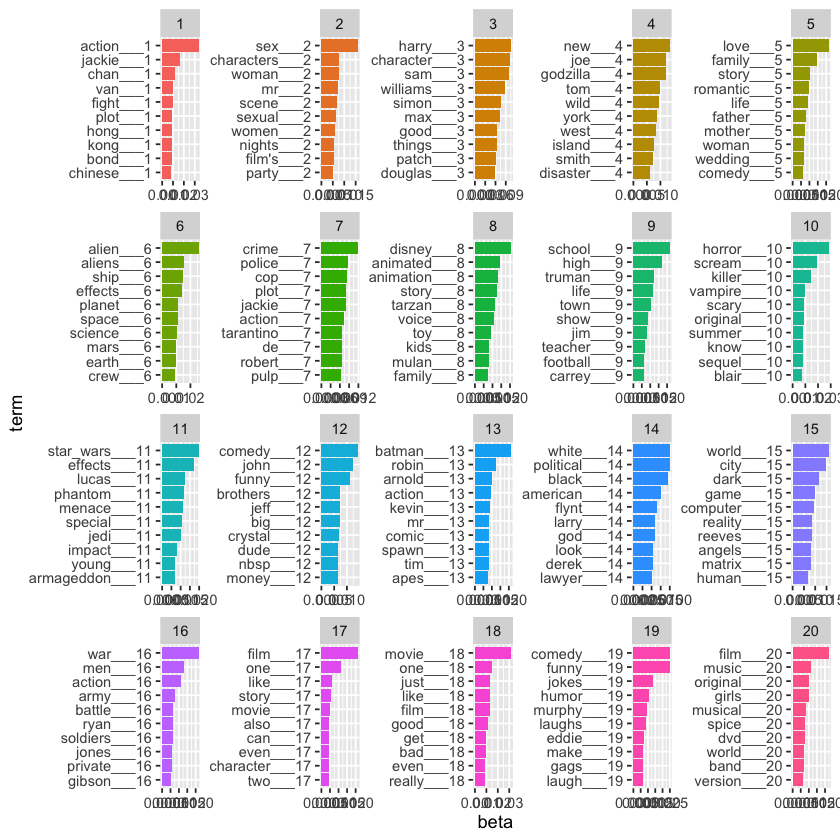

In [81]:
topterms %>%
  mutate(term = reorder_within(term, beta,topic)) %>%
  ggplot(aes(term, beta, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  # specifies bar charts, removes legend
  facet_wrap(~ topic, scales = "free") +
  # creates separate plots by topic, with x-axis scale independent of each other
  coord_flip()
  # flips x and y axes

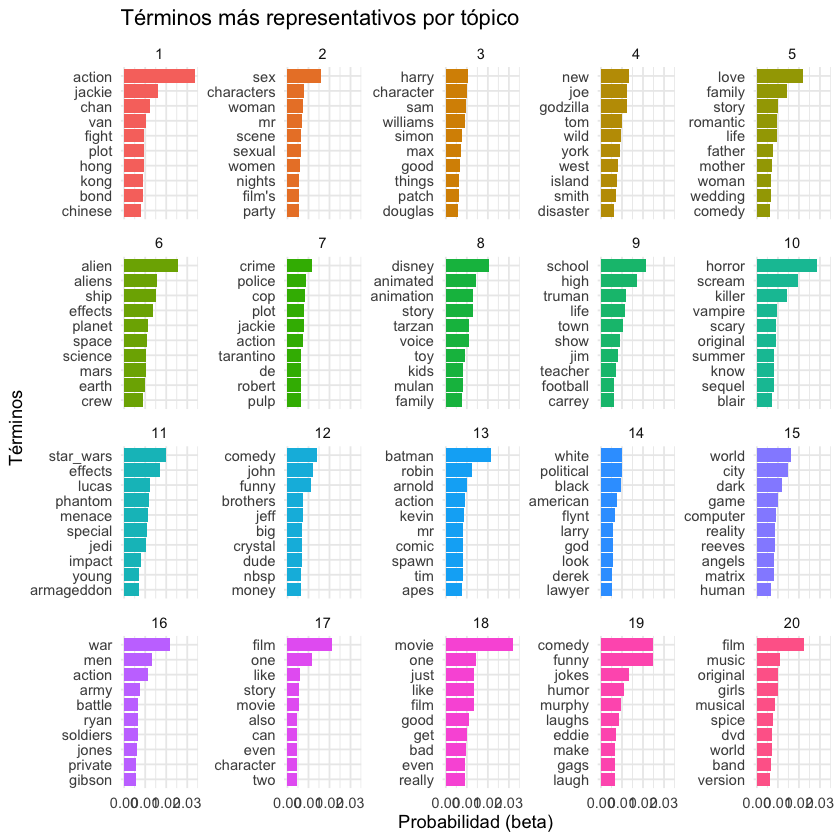

In [82]:
topterms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(x = beta, y = term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free_y") +
  scale_y_reordered() +
  theme_minimal() +
  labs(x = "Probabilidad (beta)", y = "Términos", title = "Términos más representativos por tópico")


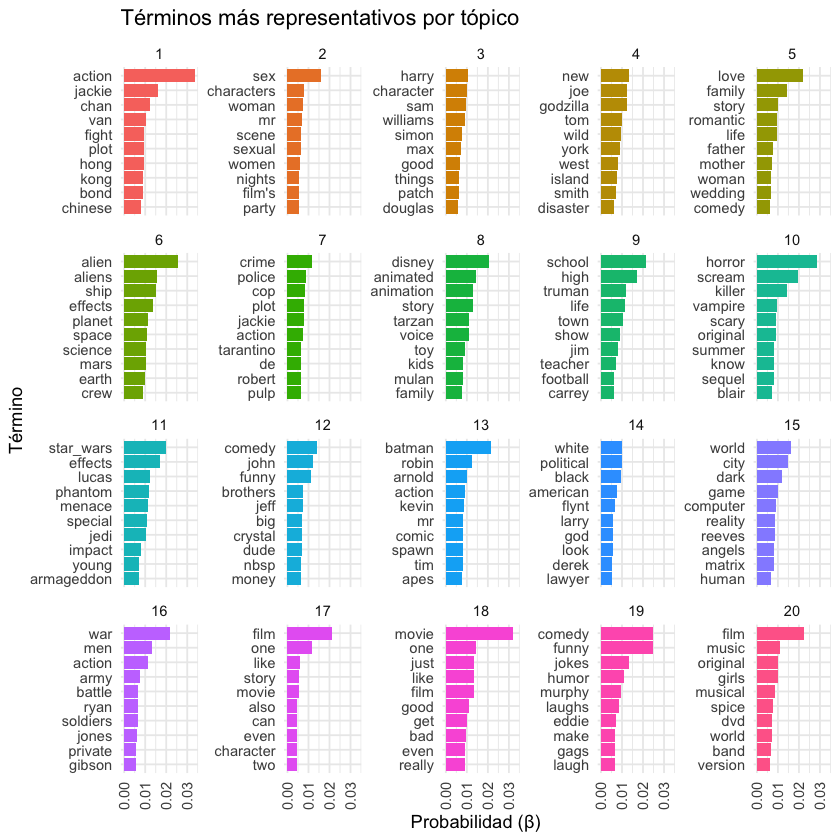

In [83]:
topterms %>%
  mutate(term = tidytext::reorder_within(term, beta, topic)) %>%
  ggplot(aes(x = beta, y = term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free_y") +
  scale_y_reordered() +
  labs(
    title = "Términos más representativos por tópico",
    x = "Probabilidad (β)",
    y = "Término"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)  # 👈 etiquetas del eje X en vertical
  )

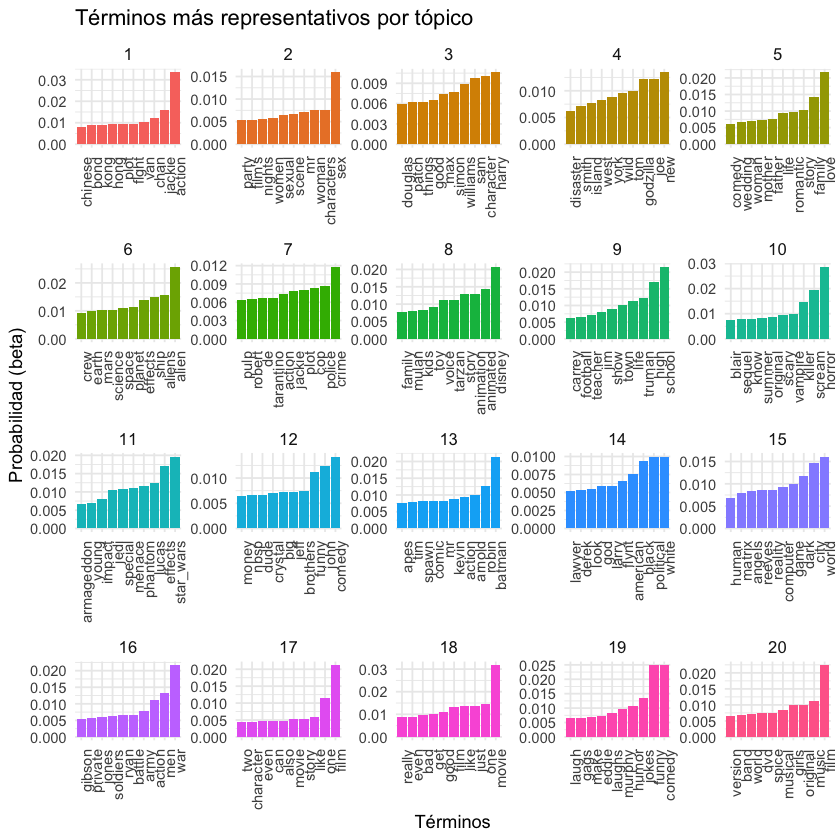

In [84]:
topterms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(x = term, y = beta, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  scale_x_reordered() +  # requiere library(tidytext)
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    strip.text = element_text(size = 10)
  ) +
  labs(x = "Términos", y = "Probabilidad (beta)", title = "Términos más representativos por tópico")


document,topic,gamma
<chr>,<int>,<dbl>
cv000_29416.txt,1,6.361323e-05
cv001_19502.txt,1,1.607717e-04
cv002_17424.txt,1,9.441824e-02
cv003_12683.txt,1,8.718396e-05
cv004_12641.txt,1,5.675369e-05
cv005_29357.txt,1,5.691520e-05
cv006_17022.txt,1,7.183908e-05
cv007_4992.txt,1,6.934813e-05
cv008_29326.txt,1,5.627462e-05


document,topic,gamma,id
<chr>,<int>,<dbl>,<int>
cv000_29416.txt,18,0.5344148,1
cv000_29416.txt,17,0.3435751,1
cv000_29416.txt,10,0.1018448,1
cv000_29590.txt,17,0.4148420,2
cv000_29590.txt,18,0.1919300,2
cv000_29590.txt,13,0.1524266,2


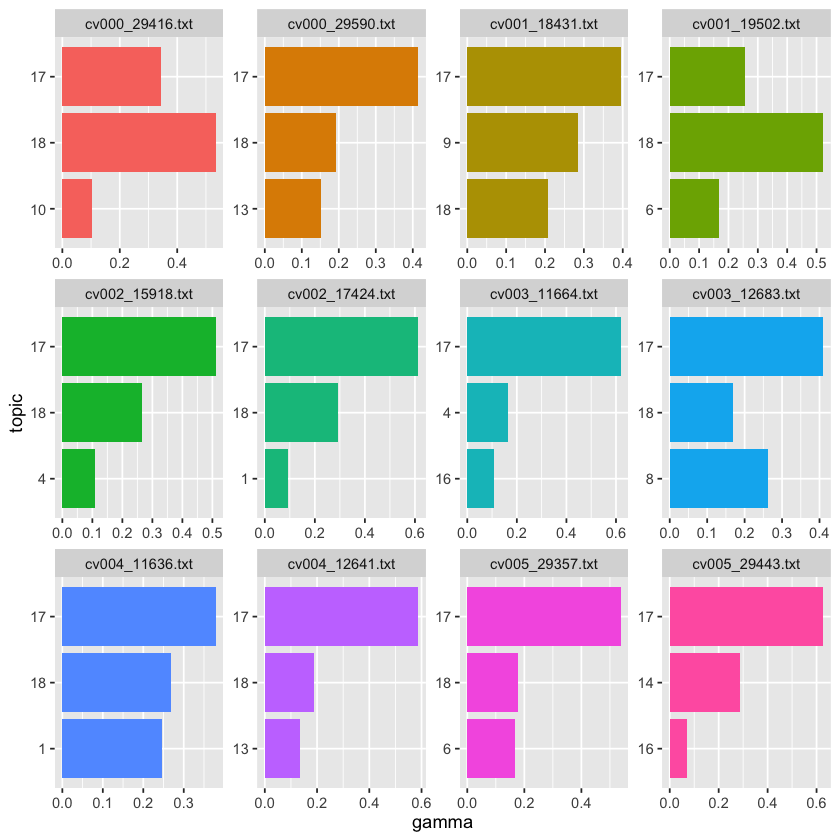

In [85]:
docs <- tidytext::tidy(tmod_20, matrix = "gamma")

head(docs, n=20)

docs_topics <-
  docs  |>
  group_by(document) |>   arrange(document, -gamma) |>
  slice_head(n=3) |> mutate(id = cur_group_id()) |> ungroup()


head(docs_topics)

docs_topics  |>  filter(id <=12) |>
  mutate(topic = reorder(topic, gamma))  |>
  ggplot(aes(topic, gamma, fill = factor(document))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ document, scales = "free") +
  coord_flip()


## 📄 Tópicos por documento

Hasta ahora hemos identificado los términos más representativos de cada tópico. Sin embargo, también es posible analizar los documentos desde la perspectiva opuesta: **¿qué tópicos predominan en cada documento?**

LDA estima, para cada documento, una distribución de probabilidades sobre los tópicos. Esto significa que un mismo documento puede estar asociado a varios tópicos en diferentes proporciones, aunque normalmente uno de ellos será el dominante.

En esta sección extraeremos esas probabilidades para identificar el tópico principal de cada documento y explorar cómo se distribuyen los tópicos a lo largo del corpus.

In [86]:
docs <- tidytext::tidy(tmod_20, matrix = "gamma")
levels(as.factor(docs$topic))



[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20"

document,topic,gamma,id
<chr>,<int>,<dbl>,<int>
cv000_29416.txt,18,0.5344148,1
cv000_29416.txt,17,0.3435751,1
cv000_29416.txt,10,0.1018448,1
cv000_29590.txt,17,0.4148420,2
cv000_29590.txt,18,0.1919300,2
cv000_29590.txt,13,0.1524266,2


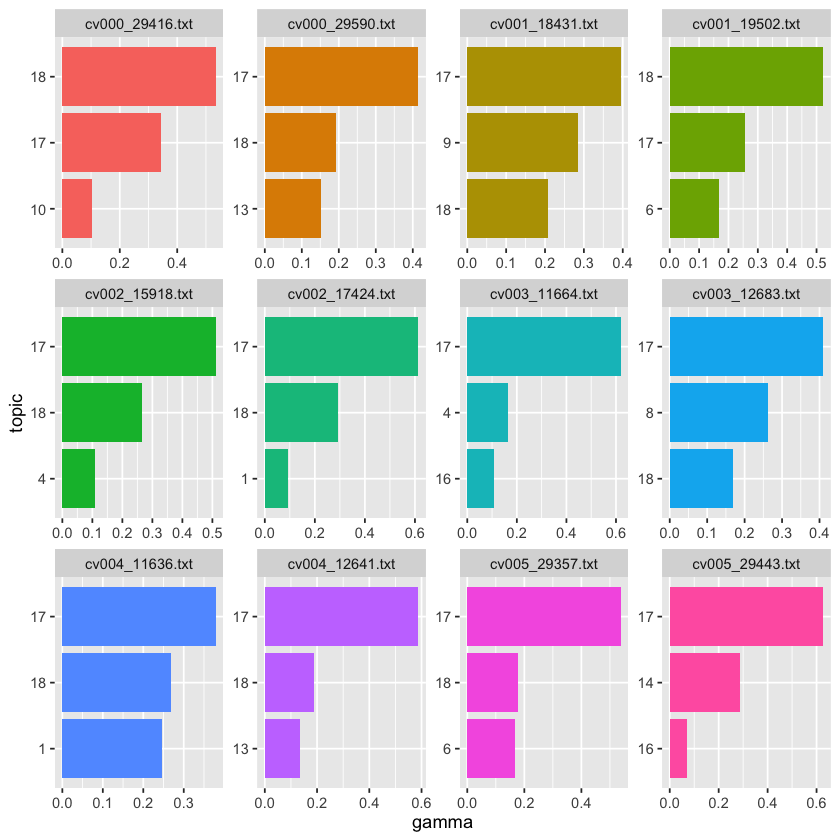

In [87]:

docs_topics <-
  docs  |>
  group_by(document) |>   arrange(document, -gamma) |>
  slice_head(n=3) |> mutate(id = cur_group_id()) |> ungroup()


head(docs_topics)

docs_topics  |>  filter(id <=12) |>
  mutate(topic = tidytext::reorder_within(topic, gamma, document))  |>
  ggplot(aes(topic, gamma, fill = factor(document))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ document, scales = "free") +
  tidytext::scale_x_reordered() +
  coord_flip()


### 🗑️ Eliminemos los tópicos residuales. Revisemos el resumen de modelos que nos entregó Claude:

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20"

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "19" "20"

document,topic,gamma,id
<chr>,<int>,<dbl>,<int>
cv000_29416.txt,10,1.018448e-01,1
cv000_29416.txt,15,1.914758e-02,1
cv000_29416.txt,1,6.361323e-05,1
cv000_29590.txt,13,1.524266e-01,2
cv000_29590.txt,20,9.034989e-02,2
cv000_29590.txt,19,3.955982e-02,2


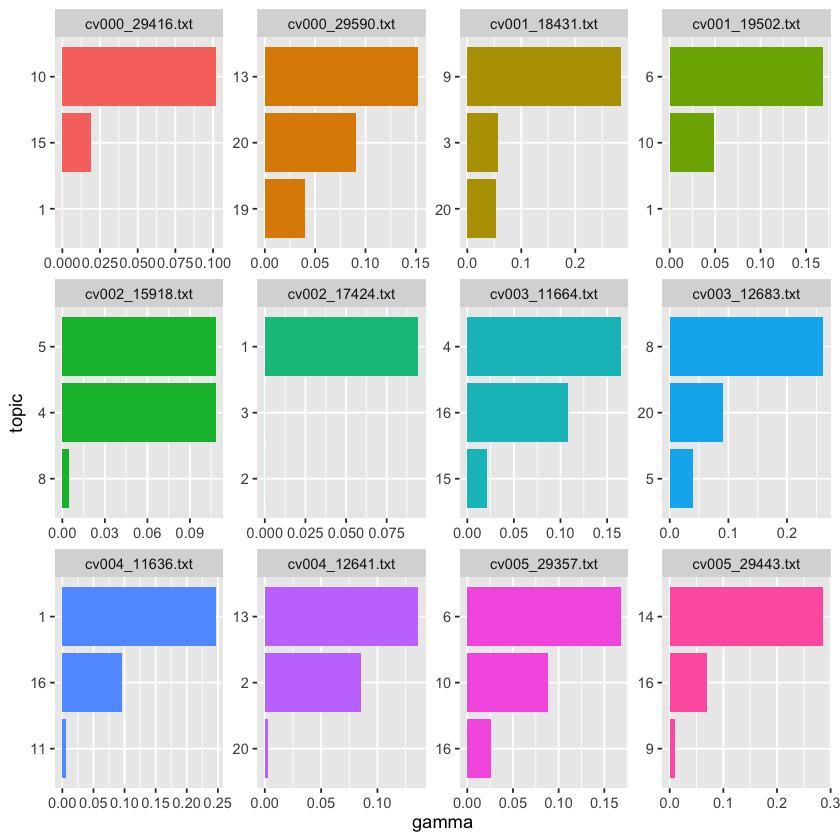

In [88]:
docs <- tidytext::tidy(tmod_20, matrix = "gamma")
levels(as.factor(docs$topic))

docs <- docs  %>% filter(topic !=17 & topic !=18)
levels(as.factor(docs$topic))

docs_topics <-
  docs  |>
  group_by(document) |>   arrange(document, -gamma) |>
  slice_head(n=3) |> mutate(id = cur_group_id()) |> ungroup()


head(docs_topics)

docs_topics  |>  filter(id <=12) |>
  mutate(topic = tidytext::reorder_within(topic, gamma, document))  |>
  ggplot(aes(topic, gamma, fill = factor(document))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ document, scales = "free") +
  tidytext::scale_x_reordered() +
  coord_flip()


### 📌 ¿Por qué algunas facetas muestran casi una sola barra?

Este modelo LDA ($k=20$) produce distribuciones $\gamma$ muy concentradas: en la mayoría de los documentos, **un solo tópico** acumula casi toda la probabilidad (gamma ≈ 0.5–0.9), mientras que el resto de los tópicos recibe valores casi nulos (a menudo entre $10^{-5}$ y $10^{-2}$).

Al excluir los tópicos 17 y 18 antes de recalcular el top-3 por documento, `slice_head(n=3)` sigue devolviendo 3 filas — pero si el 2º o 3er tópico favorito de un documento era uno de los excluidos, el reemplazo suele tener un $\gamma$ casi nulo. La barra dominante se ve normal, mientras que las otras dos son tan pequeñas que casi no se distinguen — de ahí la impresión de que el documento "solo tiene una barra".

---

## IV. Perplexity

La **perplejidad** es una métrica de evaluación (*goodness-of-fit*) ampliamente utilizada para medir la calidad de modelos de lenguaje probabilísticos, como el modelo **Latent Dirichlet Allocation (LDA)**.

### 📌 ¿Qué mide?

Indica **cuán bien** un modelo predice un conjunto de datos **desconocido** (no visto durante el entrenamiento). En términos simples:

- 🔽 **Menor perplejidad** → mejor desempeño del modelo para generalizar y predecir.
- 🔼 **Mayor perplejidad** → el modelo tiene mayor incertidumbre y peor capacidad de predicción.

### 🧮 ¿Cómo se calcula?

Se basa en la **probabilidad promedio logarítmica inversa** que el modelo asigna a las palabras del conjunto de prueba. Si el modelo asigna **altas probabilidades** a las palabras verdaderas, su perplejidad será **baja**.


$\text{Perplexity}(D) = \exp\left\{-\frac{1}{N} \sum_{d \in D} \log p(w_d) \right\}$


donde:
- \( D \) es el conjunto de documentos de prueba.
- \( w_d \) son las palabras en el documento \( d \).
- $( p(w_d) )$ es la probabilidad de esas palabras según el modelo.
- \( N \) es el número total de palabras en \( D \).

### 📈 Aplicación en LDA

Cuando se entrena un modelo LDA con diferentes valores de \( k \) (número de tópicos), se puede comparar la **perplejidad** para encontrar el valor de \( k \) que mejor generaliza. Sin embargo, valores muy bajos de perplejidad pueden coincidir con **tópicos menos interpretables**, por lo que también se debe considerar la **coherencia temática**.

🔗 Recursos útiles:

- [Gráfico de perplejidad según número de tópicos (ResearchGate)](https://www.researchgate.net/figure/Perplexity-of-LDA-models-with-different-numbers-of-topics-and-alpha-Notes-The-line-graph_fig2_283671339)
- [Tutorial Quanteda - Topic Models](https://tutorials.quanteda.io/machine-learning/topicmodel/)


In [89]:
dfm <-dfmat
dtm <-dfmat_tm   #"Document Term Matrix" - Esta es nuesta dfm con el formato para aplicar topic modelling

---

## División del Corpus en Entrenamiento y Prueba

Para evaluar la capacidad predictiva de un modelo (como LDA), es común dividir el corpus en dos subconjuntos:

- **Entrenamiento (`train`)**: utilizado para ajustar el modelo.
- **Prueba (`test`)**: utilizado para evaluar qué tan bien generaliza el modelo a datos no vistos.

A continuación se muestra el procedimiento en R para realizar esta división a partir de una `Document-Term Matrix (dtm)`:

```r
# Selecciona aleatoriamente el 75% de los documentos
train = sample(rownames(dtm), nrow(dtm) * .75)

# Crea el conjunto de entrenamiento
dtm_train = dtm[rownames(dtm) %in% train, ]

# Crea el conjunto de prueba con el 25% restante
dtm_test = dtm[!rownames(dtm) %in% train, ]
```


In [90]:
train = sample(rownames(dtm), nrow(dtm) * .75)
dtm_train = dtm[rownames(dtm) %in% train, ]
dtm_test = dtm[!rownames(dtm) %in% train, ]

In [91]:
m = LDA(dtm_train, method = "Gibbs", k = 20,  control = list(alpha = 0.02, delta = 0.02))

In [92]:
perplexity(m, dtm_test)

[1] 3761.407

---

## Evaluación de Perplejidad para Distintos Valores de \( k \)

Una forma común de seleccionar el número óptimo de tópicos en un modelo LDA es mediante la **perplejidad**, una métrica que evalúa qué tan bien un modelo de lenguaje puede generalizar a datos nuevos.

En este experimento, se entrena un modelo LDA para distintos valores de \( k \) (número de tópicos) y se calcula su perplejidad usando un conjunto de prueba independiente. El procedimiento se realiza sobre los siguientes valores de \( k \):  
**5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55 y 60**.

Para cada valor de \( k \), se construye un modelo LDA utilizando **Gibbs Sampling** con parámetros de suavizado fijos (alpha y delta = 0.02). Luego, se evalúa su capacidad de predicción sobre el conjunto de test calculando su perplejidad.

📌 **Interpretación de la perplejidad**:
- Una perplejidad **más baja** indica un mejor ajuste del modelo al capturar la estructura latente del texto.
- Una perplejidad **alta** sugiere que el modelo no generaliza bien a nuevos datos (es decir, hace malas predicciones sobre el contenido).

⚠️ Este procedimiento puede tardar **más de 20 minutos**, dependiendo del tamaño del corpus y la capacidad de procesamiento del equipo.

🎯 El objetivo es encontrar un valor de \( k \) que ofrezca un buen equilibrio entre complejidad del modelo y capacidad explicativa sin sobreajuste.


In [93]:
## crear un marco de datos para almacenar el perplexity para diferentes valores de k (esto se demora 22 minutos en el Alienware)
p = data.frame(k = c(5,10,15,20,25,30,35,40,45,50,55,60), perplexity = NA)

## recorrer los valores de k en data.frame p
for (i in 1:nrow(p)) {
  print(p$k[i])
  m = LDA(dtm_train, method = "Gibbs", k = p$k[i],  control = list(alpha = 0.02, delta = 0.02))
  p$perplexity[i] = perplexity(m, dtm_test)
}

head(p)

[1] 5
[1] 10
[1] 15
[1] 20
[1] 25
[1] 30
[1] 35
[1] 40
[1] 45
[1] 50
[1] 55
[1] 60


,k,perplexity
,<dbl>,<dbl>
1,5,4130.805
2,10,3941.638
3,15,3833.879
4,20,3750.323
5,25,3683.902
6,30,3642.083


## Escogiendo $k$ : *The Elbow Method*

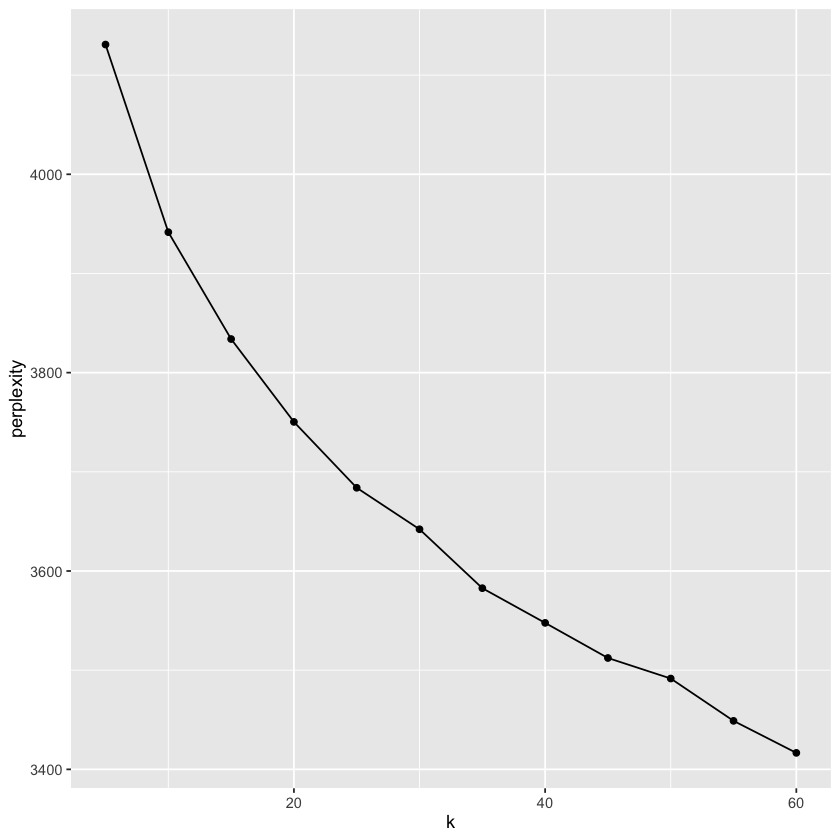

In [110]:
ggplot(p, aes(x=k, y=perplexity)) + geom_line() + geom_point()

In [95]:
p
str(p)


k,perplexity
<dbl>,<dbl>
5,4130.805
10,3941.638
15,3833.879
20,3750.323
25,3683.902
30,3642.083
35,3582.686
40,3547.694
45,3512.286


'data.frame':	12 obs. of  2 variables:
 $ k         : num  5 10 15 20 25 30 35 40 45 50 ...
 $ perplexity: num  4131 3942 3834 3750 3684 ...


https://stackoverflow.com/questions/71856782/elbow-method-for-optimal-no-of-clusters

https://community.ibm.com/community/user/ai-datascience/blogs/moloy-de1/2020/07/02/points-to-ponder

https://www.researchgate.net/figure/Example-of-the-elbow-criterion-applied-over-the-curve-of-within-class-sum-of-squares-per_fig1_281443471

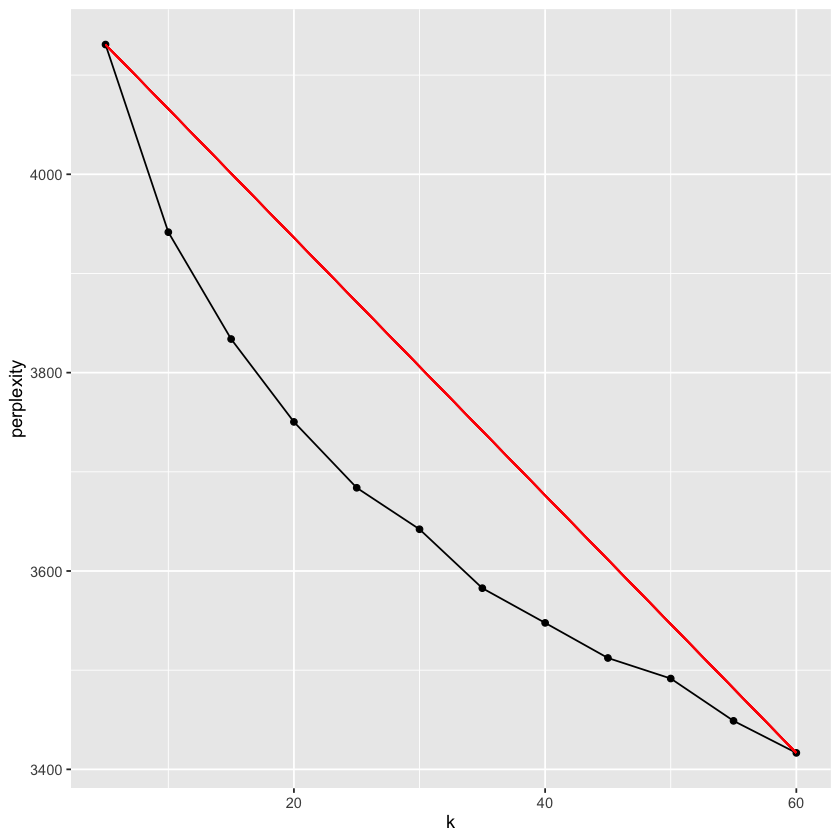

In [111]:
suppressWarnings(print(
  p  %>% ggplot(aes(x=k, y=perplexity)) + geom_line() + geom_point() +
       geom_segment(aes(x = k[1], y = perplexity[1], xend = k[12], yend = perplexity[12]), col="red")
))



### **Distancia de un Punto a una Recta**

Considere la recta:

$L: y=mx + n$ y el punto $P=(a,b)$

La distancia entre el punto y la recta viene dada por:

$d(P,L)= \frac{ | b-m\cdot a-n | }{ \sqrt{a^2+1} } $  



https://www.superprof.es/apuntes/escolar/matematicas/analitica/distancias/distancia-de-un-punto-a-una-recta.html

https://es.wikipedia.org/wiki/Distancia_de_un_punto_a_una_recta


In [97]:
# Esta función calcula la distancia entre el punto "P" y la recta L.

dist_PL <- function(m,n,Px,Py) {
    d <- (abs(Py-m*Px-n))/sqrt(m^2+1)
} 

¿Cuál es la distancia del segundo punto (k=10) a la recta?

La pendiente es:

In [98]:
m <- (p$perplexity[nrow(p)]-p$perplexity[1])/ (p$k[nrow(p)]-p$k[1])
m

[1] -12.98515

El intercepto es:

In [99]:
n <- p$perplexity[nrow(p)]-m*p$k[nrow(p)]
n

[1] 4195.731

In [100]:
d <- dist_PL(m,n,p$k[2],p$perplexity[2])
d

[1] 9.539674

Calculemos las distancias de todos los puntos a la recta: 

In [101]:
dist_vector = data.frame(k = c(5,10,15,20,25,30,35,40,45,50,55,60), dist = NA) #En este vector guardamos las distancias

In [102]:
for (i in 1:nrow(p)) {
  dist_vector$dist[i] = dist_PL(m,n,p$k[i],p$perplexity[i])
}

In [103]:
dist_vector


k,dist
<dbl>,<dbl>
5,0.000000
10,9.539674
15,12.828586
20,14.259141
25,14.373904
30,12.599708
35,12.175158
40,9.876756
45,7.610264


In [104]:
print(dist_vector$k[which.max(dist_vector$dist)])


[1] 25


El número óptimo de tópicos es entonces 20.

Y....¿si hacemos el gráfico?

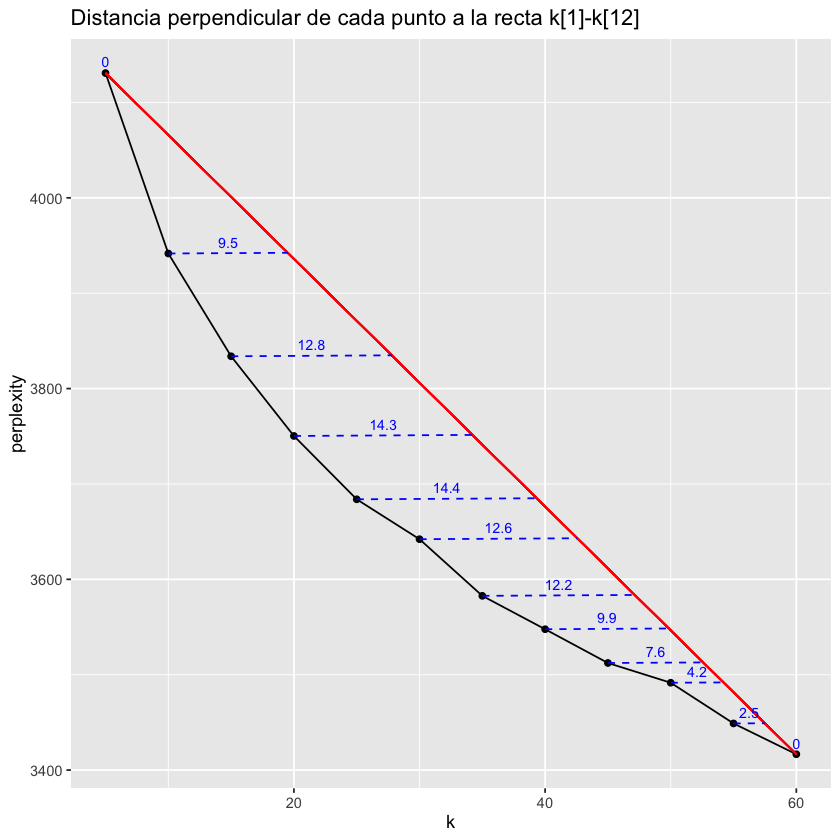

In [109]:
# Para cada punto, dibujamos el segmento perpendicular a la recta k[1]-k[12]
# (usando la pendiente "m" y el intercepto "n" ya calculados) y anotamos
# la distancia real de cada punto a la recta (dist_vector$dist).

p_dist <- p
p_dist$foot_x <- (p_dist$k + m * (p_dist$perplexity - n)) / (1 + m^2)
p_dist$foot_y <- n + m * p_dist$foot_x
p_dist$dist   <- dist_vector$dist

suppressWarnings(print(
  p_dist %>%
    ggplot(aes(x = k, y = perplexity)) +
    geom_line() +
    geom_point() +
    geom_segment(aes(x = k[1], y = perplexity[1], xend = k[12], yend = perplexity[12]), col = "red") +
    geom_segment(aes(x = k, y = perplexity, xend = foot_x, yend = foot_y), col = "blue", linetype = "dashed") +
    geom_text(aes(x = (k + foot_x) / 2, y = (perplexity + foot_y) / 2, label = round(dist, 1)),
              vjust = -0.6, size = 3, color = "blue") +
    labs(title = "Distancia perpendicular de cada punto a la recta k[1]-k[12]")
))


### 📌 ¿Por qué los segmentos no se ven en ángulo recto?

Los segmentos azules **sí son perpendiculares** a la recta roja — matemáticamente. Se calculan proyectando cada punto sobre la recta $y = mx + n$ (el mismo `m` y `n` ya calculados más arriba), y su pendiente resulta exactamente $-1/m$, la pendiente perpendicular (la misma que usa `m1` más abajo). Su longitud coincide con `dist_vector$dist`, calculada con la fórmula de distancia punto-recta (`dist_PL()`) definida al inicio de esta sección.

Lo que **no coincide** es la apariencia visual. `ggplot2` escala los ejes X (`k`, rango ≈ 5–60) e Y (`perplexity`, rango de cientos o miles) de forma **independiente** para llenar el panel. Un ángulo de 90° en el espacio de los datos deja de verse como 90° en la pantalla salvo que ambos ejes usen la **misma escala física** — algo que solo se logra forzando `coord_fixed(ratio = 1)`.

Probamos esa opción, pero el resultado fue un gráfico extremadamente alto y angosto (dado lo distintas que son las escalas de `k` y `perplexity`), difícil de leer. Por eso se mantiene el escalado automático: los **valores de distancia** que se muestran junto a cada segmento son correctos, aunque el ángulo no se vea literalmente recto.

> 💡 **Idea clave:** en gráficos con ejes de escalas muy distintas, "perpendicular" es una propiedad del espacio de los datos, no necesariamente de lo que se observa visualmente en pantalla.

---
## 🤖 Utilizando un LLM para evaluar la interpretabilidad de distintos valores de $k$

Hasta ahora hemos comparado los modelos LDA mediante una inspección visual de sus tópicos. Sin embargo, los **Modelos de Lenguaje de Gran Escala (LLMs)** también pueden utilizarse como una herramienta complementaria para evaluar la **calidad semántica** de los tópicos obtenidos.

En particular, un LLM puede analizar las palabras más representativas de cada tópico y ayudar a responder preguntas como:

- ¿Los tópicos son internamente coherentes?
- ¿Existen tópicos redundantes o muy similares?
- ¿Algunos tópicos son demasiado generales o demasiado específicos?
- ¿Qué modelo produce tópicos más fáciles de interpretar?

---

### 🧠 ¿Qué puede evaluar un LLM?

A partir de las palabras con mayor probabilidad de cada tópico, un LLM puede proporcionar una evaluación cualitativa de aspectos como:

- **Coherencia semántica** de cada tópico.
- **Redundancia** entre tópicos.
- **Nivel de especificidad** de los temas identificados.
- **Interpretabilidad** general del modelo.

Estas observaciones pueden complementar el análisis realizado por el investigador y facilitar la comparación entre modelos estimados con distintos valores de $k$.

---

### ⚠️ Importante

Un LLM **no determina el valor óptimo de $k$**, ni reemplaza las métricas estadísticas utilizadas en Topic Modelling.

Su papel consiste en **asistir la interpretación cualitativa** de los tópicos obtenidos, complementando medidas como:

- coherencia temática;
- log-verosimilitud;
- perplexity;
- validación cruzada.

---

> 💡 En las siguientes secciones exportaremos los tópicos generados por los modelos con $k=12$, $k=20$ y $k=25$, y utilizaremos un LLM de código abierto para comparar su coherencia e interpretabilidad.

---
## 💾 Exportar los tópicos ($k=12, 20, 25$) para evaluarlos con un LLM en Python

Para poder comparar la **coherencia semántica** de los tres modelos con un LLM (por ejemplo, `meta-llama/Meta-Llama-3-8B-Instruct`), exportamos las palabras más representativas de cada tópico a un archivo CSV por modelo.

Para cada modelo, usamos el mismo flujo ya utilizado en la sección de la matriz beta: convertimos el modelo a formato *tidy* con `tidytext::tidy(modelo, matrix = "beta")` y conservamos, para cada tópico, las 15 palabras con mayor probabilidad ($\beta$).

> 📌 Al igual que en la Unidad 4b, el archivo se guarda en el directorio de trabajo actual de R (`getwd()`) y se referencia luego en Python solo por su nombre.

In [106]:
export_topterms <- function(modelo, k, n = 15) {
  tidytext::tidy(modelo, matrix = "beta") %>%
    group_by(topic) %>%
    top_n(n, beta) %>%
    ungroup() %>%
    arrange(topic, -beta) %>%
    mutate(k = k)
}

topterms_12 <- export_topterms(tmod_12, k = 12)
topterms_20 <- export_topterms(tmod_20, k = 20)
topterms_25 <- export_topterms(tmod_25, k = 25)

write_csv(topterms_12, "lda_topterms_k12.csv")
write_csv(topterms_20, "lda_topterms_k20.csv")
write_csv(topterms_25, "lda_topterms_k25.csv")

head(topterms_12)

topic,term,beta,k
<int>,<chr>,<dbl>,<dbl>
1,action,0.022739317,12
1,jackie,0.011834171,12
1,plot,0.006915254,12
1,crime,0.006590420,12
1,cop,0.006265586,12
1,chan,0.005476703,12
